In [18]:
import os, yaml, sys
import numpy as np
import matplotlib.pyplot as plt
import h5py
from IPython.display import clear_output
import random
from scipy.io import loadmat
ENV = os.getenv("MY_ENV", "dev")
with open("../../config.yaml", "r") as f:
    config = yaml.safe_load(f)
paths = config[ENV]["paths"]
sys.path.append(paths["src_path"])
sys.path.append(paths["useful_stuff_path"])
from useful_stuff.general_utils.utils import TimeSeries, compatible_TimeSeries_check, print_wise, get_lagplot
# from useful_stuff.general_utils.RSA import  dRSA
# from useful_stuff.general_utils.II import  dRSA, dynInformationImbalance
from useful_stuff.image_processing.computational_models import get_relevant_output_layers
from project_specific_utils.dataloader import load_concat_regressout_meg
from analyses.subsampling_lagged_comparisons import get_spaced_pseudotrials
# from image_processing.gaze_dep_models import save_ANN_features


In [ ]:
def plot_rsa(tot_rsa, neu_fs, max_lag, title=None, tick_step=20):
    fig, ax = plt.subplots(1, 2, figsize=(10, 4))

    # --- heatmap ---
    ax[0].imshow(tot_rsa)

    ticks = np.arange(-max_lag, max_lag + 1, tick_step)
    ticks_labels = np.round(ticks / neu_fs, 2)
    ticks += max_lag

    # --- lag plot ---
    lagplot = get_lagplot(tot_rsa, max_lag=max_lag)
    ax[1].plot(lagplot)

    ax[1].set_ylabel("dRSA similarity")
    ax[1].set_xlabel("lag [sec]")
    ax[1].set_xticks(ticks, ticks_labels)
    ax[1].axvline(max_lag, color="r", linestyle="--", linewidth=1)

    # --- 🔥 compute peak ---
    peak_idx = np.argmax(lagplot)
    peak_val = lagplot[peak_idx]
    peak_lag = (peak_idx - max_lag) / neu_fs  # convert to seconds

    # --- 🔥 textbox ---
    textstr = f"magnitude: {peak_val:.3f}\nlag: {peak_lag:.2f}s"
    ax[1].text(
        0.05, 0.95, textstr,
        transform=ax[1].transAxes,
        fontsize=10,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.7)
    )

    # --- labels ---
    ax[0].set_xlabel(f"Model time, length={tot_rsa.shape[1]/neu_fs}sec")
    ax[0].set_ylabel(f"Neural time, length={tot_rsa.shape[1]/neu_fs}sec")
    ax[0].set_xticks([])
    ax[0].set_yticks([])

    fig.suptitle(title, fontsize=20)
    plt.tight_layout()



In [187]:
from dataclasses import dataclass, field

@dataclass
class Cfg:
    sub_num = 4
    neu_fs = 100
    gaze_fs = 50
    sq_side = 384
    tick_step = 100
    sensors_group = 'occ'
    model_name = "dino_v3_l"
    pkg = "hf"
    pseudotrial_len_timepts = 1000
    max_lag = 500
    pseudotrials_n = 100
    full_model_name = "alexnet_features.4"
    n_model_components = 1000
    pooling = "all"
    PCs_to_regress_out = 50
    timepts_to_regress_out = (-100, 100)
    iterations_n = 10
    repetition = 0
    signal_metric = "correlation"
    model_metric = "correlation"
    regress_out_gaze = 'PCR' # or None or pointwise
    PCs_to_regress_out = 50
    analysis_type = "RSA"
cfg = Cfg()
layers = get_relevant_output_layers(cfg.model_name, cfg.pkg)
mod_fs = config["movie_fs"]
model_len = [round(i*cfg.neu_fs/config["movie_fs"]) for i in config["model_len"]]

In [188]:
# """
# multivariate_lagged_comparisons
# Performs multivariate lagged comparisons (RSA or II) between neural and model data, and saves the results to disk.

# INPUT:
#     - paths: dict[str, str] -> project path dictionary
#     - n: TimeSeries -> neural signal (features x timepoints)
#     - analysis_type: str -> type of analysis ("RSA" or "II")
#     - sub_num: int -> subject number
#     - sensors_group: str -> MEG sensors group
#     - repetition: int -> repetition index (selects runs)
#     - full_model_name: str -> model/layer name
#     - iterations_n: int -> number of subsampling iterations
#     - pseudotrial_len: int -> length of pseudotrials (in timepoints)
#     - neu_fs: float -> sampling frequency of neural data
#     - signal_metric: str -> distance/similarity metric for neural data
#     - model_metric: str -> distance/similarity metric for model data
#     - pseudotrials_n: int -> number of pseudotrials per iteration
#     - sq_side: int -> spatial patch size used for model features
#     - regress_out_gaze: bool | str -> whether/how gaze regression is applied (used for naming)
#     - n_model_components: int -> number of PCA components for model features
#     - pooling: str (default="all") -> pooling type for model features
#     - rank: int (default=0) -> process rank for logging

# OUTPUT:
#     - None -> results are saved to disk as .mat files
#         - RSA: saves a single matrix (time x time)
#         - II: saves two matrices (A2B and B2A directions)
# """
# def multivariate_lagged_comparisons(paths, n, analysis_type, sub_num, sensors_group, repetition, full_model_name, iterations_n, pseudotrial_len, neu_fs, signal_metric, model_metric, pseudotrials_n, sq_side, regress_out_gaze, n_model_components, pooling="all", rank=0):
#     if cfg.analysis_type == "RSA":
#         p = [save_lagged_comparisons(paths, analysis_type, sub_num, sensors_group, i_rep, full_model_name, iterations_n, pseudotrial_len, neu_fs, signal_metric=signal_metric, model_metric=model_metric, pseudotrials_n=pseudotrials_n, sq_side=sq_side, regress_out_gaze=regress_out_gaze),]
#     elif cfg.analysis_type == "II":
#         p = []
#         pA2B = save_lagged_comparisons(paths, analysis_type+"A2B", sub_num, sensors_group, i_rep, full_model_name, iterations_n, pseudotrial_len, neu_fs, signal_metric=signal_metric, model_metric=model_metric, pseudotrials_n=pseudotrials_n, sq_side=sq_side, regress_out_gaze=regress_out_gaze)
#         p.append(pA2B)
#         pB2A = save_lagged_comparisons(paths, cfg.analysis_type+"B2A", sub_num, sensors_group, i_rep, full_model_name, iterations_n, pseudotrial_len, neu_fs, signal_metric=signal_metric, model_metric=model_metric, pseudotrials_n=pseudotrials_n, sq_side=sq_side, regress_out_gaze=regress_out_gaze)
#         p.append(pB2A)
#     if all(os.path.exists(path) for path in p):
#         print(f"{p[0]} already exists")
#         return None
#     m = load_concat_regressout_mod(paths, sub_num, save_ANN_features, full_model_name, repetition, mod_fs, neu_fs, *(sq_side, n_model_components, pooling), regress_out_gaze=False, gaze_dep=True, gaze_fs=50, rank=rank,)
#     tot_A2B, tot_B2A = subsampling_lagged_comparisons(n, m, pseudotrial_len, iterations_n, pseudotrials_n, model_len, subsampling_RSA, rank, *(signal_metric, model_metric))
#     if not cfg.regress_out_gaze:
#         cfg.regress_out_gaze = "0"
#     if cfg.analysis_type == "RSA":
#         savemat(p[0], {"RSA": tot_A2B})
#         print_wise(f"{full_model_name} saved at {p[0]}")
#     elif cfg.analysis_type == "II":
#         savemat(p[0], {"II": tot_A2B})
#         savemat(p[1], {"II": tot_B2A})
#         print_wise(f"{full_model_name} saved at {p[0]}")
#     return None

In [189]:
from project_specific_utils.dataloader import load_concat_regressout_mod
from image_processing.gaze_dep_models import save_ANN_features
rank=0
full_model_name = f"{cfg.model_name}_{layers[0]}"
m_low = load_concat_regressout_mod(paths, cfg.sub_num, save_ANN_features, full_model_name, cfg.repetition, mod_fs, cfg.neu_fs, *(cfg.sq_side, cfg.n_model_components, cfg.pooling), regress_out_gaze=False, gaze_dep=True, gaze_fs=50, rank=rank,)
full_model_name = f"{cfg.model_name}_{layers[15]}"
m_high = load_concat_regressout_mod(paths, cfg.sub_num, save_ANN_features, full_model_name, cfg.repetition, mod_fs, cfg.neu_fs, *(cfg.sq_side, cfg.n_model_components, cfg.pooling), regress_out_gaze=False, gaze_dep=True, gaze_fs=50, rank=rank,)



16:25:38 - rank 0 Loading model dino_v3_l_layer.0.mlp.down_proj: regress_out_gaze=False
16:25:39 - rank 0 dino_v3_l_layer.0.mlp.down_proj: shape runs [1 2 3]: [(1000, 87379), (1000, 86278), (1000, 79071)]
16:25:39 - rank 0 Loading model dino_v3_l_layer.15.mlp.down_proj: regress_out_gaze=False
16:25:40 - rank 0 dino_v3_l_layer.15.mlp.down_proj: shape runs [1 2 3]: [(1000, 87379), (1000, 86278), (1000, 79071)]


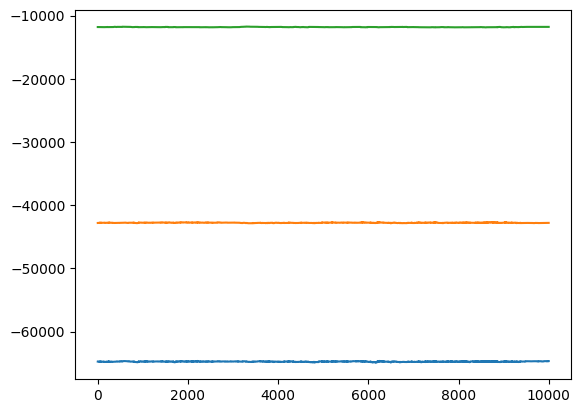

In [191]:

marray = m_low.get_array()
plt.plot(marray[:3, :10000].T)

In [167]:
pseudotrials_idx = get_spaced_pseudotrials(m, cfg.pseudotrial_len_timepts, cfg.pseudotrials_n, 5,discontinuities=model_len)

In [168]:
m.shape()

(1000, 252728)

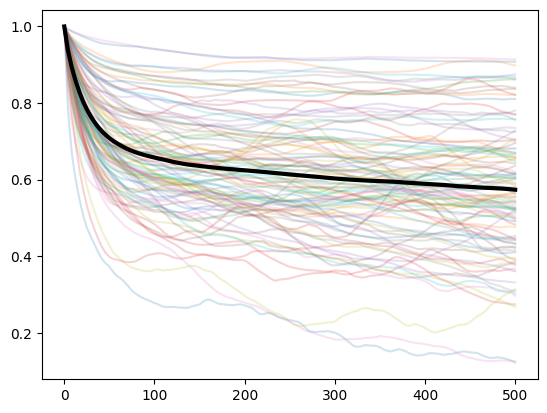

In [169]:
avg_line = []
for i_st in pseudotrials_idx:
    m_sample = TimeSeries(m[i_st:i_st+cfg.pseudotrial_len_timepts], cfg.neu_fs)
    mat, line = m_sample.autocorr(max_lag=cfg.max_lag)
    avg_line.append(line)
    plt.plot(line, alpha=.2)
avg_line = np.stack(avg_line, axis=0).mean(axis=0)
plt.plot(avg_line, linewidth=3, color="k");

16:26:20 - rank 0 Loading model dino_v3_l_layer.0.mlp.down_proj: regress_out_gaze=False
16:26:21 - rank 0 dino_v3_l_layer.0.mlp.down_proj: shape runs [1 2 3]: [(1000, 87379), (1000, 86278), (1000, 79071)]
16:26:22 - rank 0 Loading model dino_v3_l_layer.1.mlp.down_proj: regress_out_gaze=False
16:26:22 - rank 0 dino_v3_l_layer.1.mlp.down_proj: shape runs [1 2 3]: [(1000, 87379), (1000, 86278), (1000, 79071)]
16:26:23 - rank 0 Loading model dino_v3_l_layer.2.mlp.down_proj: regress_out_gaze=False
16:26:24 - rank 0 dino_v3_l_layer.2.mlp.down_proj: shape runs [1 2 3]: [(1000, 87379), (1000, 86278), (1000, 79071)]
16:26:25 - rank 0 Loading model dino_v3_l_layer.3.mlp.down_proj: regress_out_gaze=False
16:26:25 - rank 0 dino_v3_l_layer.3.mlp.down_proj: shape runs [1 2 3]: [(1000, 87379), (1000, 86278), (1000, 79071)]
16:26:26 - rank 0 Loading model dino_v3_l_layer.4.mlp.down_proj: regress_out_gaze=False
16:26:27 - rank 0 dino_v3_l_layer.4.mlp.down_proj: shape runs [1 2 3]: [(1000, 87379), (1000

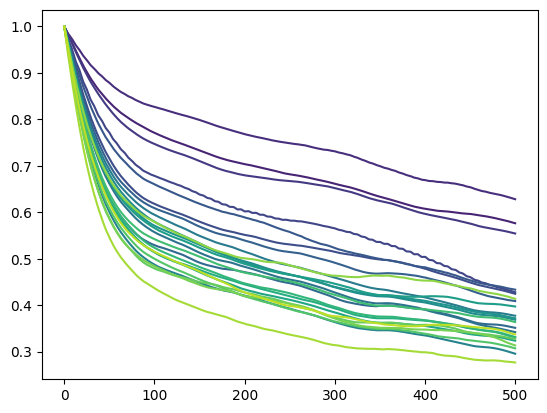

In [192]:
from useful_stuff.general_utils.RSA import dRSA
from useful_stuff.general_utils.plots import truncate_colormap

cmap = truncate_colormap(plt.cm.viridis)  # or "plasma", "coolwarm", etc.
colors = cmap(np.linspace(0, 1,len(layers)))
for idx, l in enumerate(layers):
    full_model_name = f"{cfg.model_name}_{l}"
    m = load_concat_regressout_mod(paths, cfg.sub_num, save_ANN_features, full_model_name, cfg.repetition, mod_fs, cfg.neu_fs, *(cfg.sq_side, cfg.n_model_components, cfg.pooling), regress_out_gaze=False, gaze_dep=True, gaze_fs=50, rank=rank,)
    trials = []
    for i_st in pseudotrials_idx:
        m_sample = m[i_st:i_st+cfg.pseudotrial_len_timepts]
        trials.append(m_sample)
    model_trials = TimeSeries(np.stack(trials, axis=2), m.get_fs())
    drsa_obj_corr = dRSA("correlation")
    drsa_obj_corr.compute_RDM_timeseries(model_trials, "model")
    m_RDM = drsa_obj_corr.get_RDM_timeseries("model")
    mat, line = m_RDM.autocorr( max_lag=cfg.max_lag)
    plt.plot(line, color=colors[idx])

14:35:42 - rank 0 Loading model vit_l_16_blocks.0.mlp.fc2: regress_out_gaze=False
14:35:42 - rank 0 vit_l_16_blocks.0.mlp.fc2: shape runs [1 2 3]: [(1000, 87379), (1000, 86278), (1000, 79071)]
14:35:43 - rank 0 Loading model vit_l_16_blocks.1.mlp.fc2: regress_out_gaze=False
14:35:44 - rank 0 vit_l_16_blocks.1.mlp.fc2: shape runs [1 2 3]: [(1000, 87379), (1000, 86278), (1000, 79071)]
14:35:45 - rank 0 Loading model vit_l_16_blocks.2.mlp.fc2: regress_out_gaze=False
14:35:45 - rank 0 vit_l_16_blocks.2.mlp.fc2: shape runs [1 2 3]: [(1000, 87379), (1000, 86278), (1000, 79071)]
14:35:46 - rank 0 Loading model vit_l_16_blocks.3.mlp.fc2: regress_out_gaze=False
14:35:46 - rank 0 vit_l_16_blocks.3.mlp.fc2: shape runs [1 2 3]: [(1000, 87379), (1000, 86278), (1000, 79071)]
14:35:48 - rank 0 Loading model vit_l_16_blocks.4.mlp.fc2: regress_out_gaze=False
14:35:48 - rank 0 vit_l_16_blocks.4.mlp.fc2: shape runs [1 2 3]: [(1000, 87379), (1000, 86278), (1000, 79071)]
14:35:49 - rank 0 Loading model vit

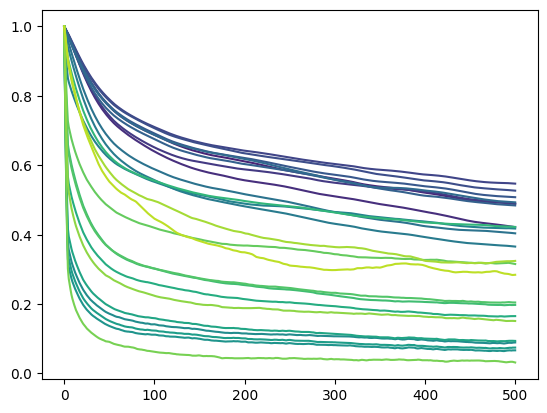

In [ ]:
from useful_stuff.general_utils.RSA import dRSA
from useful_stuff.general_utils.plots import truncate_colormap

cmap = truncate_colormap(plt.cm.viridis)  # or "plasma", "coolwarm", etc.
colors = cmap(np.linspace(0, 1,len(layers)))
for idx, l in enumerate(layers):
    full_model_name = f"{cfg.model_name}_{l}"
    m = load_concat_regressout_mod(paths, cfg.sub_num, save_ANN_features, full_model_name, cfg.repetition, mod_fs, cfg.neu_fs, *(cfg.sq_side, cfg.n_model_components, cfg.pooling), regress_out_gaze=False, gaze_dep=True, gaze_fs=50, rank=rank,)
    trials = []
    for i_st in pseudotrials_idx:
        m_sample = m[i_st:i_st+cfg.pseudotrial_len_timepts]
        trials.append(m_sample)
    model_trials = TimeSeries(np.stack(trials, axis=2), m.get_fs())
    drsa_obj_corr = dRSA("correlation")
    drsa_obj_corr.compute_RDM_timeseries(model_trials, "model")
    m_RDM = drsa_obj_corr.get_RDM_timeseries("model")
    mat, line = m_RDM.autocorr( max_lag=cfg.max_lag)
    plt.plot(line, color=colors[idx])

15:38:18 - rank 0 Loading model dino_v3_l_layer.0.mlp.down_proj: regress_out_gaze=False
15:38:18 - rank 0 dino_v3_l_layer.0.mlp.down_proj: shape runs [1 2 3]: [(1000, 87379), (1000, 86278), (1000, 79071)]
15:38:18 - rank 0 Loading model dino_v3_l_layer.1.mlp.down_proj: regress_out_gaze=False
15:38:19 - rank 0 dino_v3_l_layer.1.mlp.down_proj: shape runs [1 2 3]: [(1000, 87379), (1000, 86278), (1000, 79071)]
15:38:22 - rank 0 Loading model dino_v3_l_layer.2.mlp.down_proj: regress_out_gaze=False
15:38:22 - rank 0 dino_v3_l_layer.2.mlp.down_proj: shape runs [1 2 3]: [(1000, 87379), (1000, 86278), (1000, 79071)]
15:38:24 - rank 0 Loading model dino_v3_l_layer.3.mlp.down_proj: regress_out_gaze=False
15:38:24 - rank 0 dino_v3_l_layer.3.mlp.down_proj: shape runs [1 2 3]: [(1000, 87379), (1000, 86278), (1000, 79071)]
15:38:26 - rank 0 Loading model dino_v3_l_layer.4.mlp.down_proj: regress_out_gaze=False
15:38:26 - rank 0 dino_v3_l_layer.4.mlp.down_proj: shape runs [1 2 3]: [(1000, 87379), (1000

Text(0.5, 0, 'time lag [sec]')

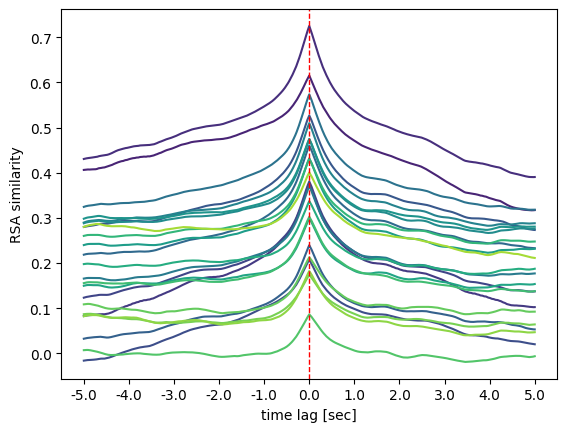

In [186]:
from useful_stuff.general_utils.RSA import dRSA
from useful_stuff.general_utils.plots import truncate_colormap
ticks = np.arange(-cfg.max_lag, cfg.max_lag + 1, cfg.tick_step)
ticks_labels = np.round(ticks / cfg.neu_fs, 2)
ticks += cfg.max_lag
cmap = truncate_colormap(plt.cm.viridis)  # or "plasma", "coolwarm", etc.
colors = cmap(np.linspace(0, 1,len(layers)))
full_model_name = f"{cfg.model_name}_{layers[0]}"
m_low = load_concat_regressout_mod(paths, cfg.sub_num, save_ANN_features, full_model_name, cfg.repetition, mod_fs, cfg.neu_fs, *(cfg.sq_side, cfg.n_model_components, cfg.pooling), regress_out_gaze=False, gaze_dep=True, gaze_fs=50, rank=rank,)
for idx, l in enumerate(layers[1:]):
    full_model_name = f"{cfg.model_name}_{l}"
    m_high = load_concat_regressout_mod(paths, cfg.sub_num, save_ANN_features, full_model_name, cfg.repetition, mod_fs, cfg.neu_fs, *(cfg.sq_side, cfg.n_model_components, cfg.pooling), regress_out_gaze=False, gaze_dep=True, gaze_fs=50, rank=rank,)
    trials_low = []
    trials_high = []
    for i_st in pseudotrials_idx:
        trials_low.append(m_low[i_st:i_st+cfg.pseudotrial_len_timepts])
        trials_high.append(m_high[i_st:i_st+cfg.pseudotrial_len_timepts])
        
    model_trials_low = TimeSeries(np.stack(trials_low, axis=2), m.get_fs())
    model_trials_high = TimeSeries(np.stack(trials_high, axis=2), m.get_fs())
    drsa_obj_corr = dRSA("correlation")
    drsa_obj_corr.compute_both_RDM_timeseries(model_trials_low, model_trials_high)
    dRSA_mat = drsa_obj_corr.compute_dRSA()
    plt.plot(get_lagplot(dRSA_mat, max_lag=cfg.max_lag), color=colors[idx])
plt.xticks(ticks, ticks_labels)
plt.axvline(cfg.max_lag, color="r", linestyle="--", linewidth=1)
plt.ylabel("RSA similarity")
plt.xlabel("time lag [sec]")